In [2]:
import numpy as np
import jax.numpy as jnp
import jax
import os
import matplotlib.pyplot as plt
import seaborn as sns
import fsps
from tqdm import tqdm
from astropy import constants as const

import h5py
import numpy as np
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
from dataclasses import dataclass
import jax
import jax.numpy as jnp
import tqdm
import blackjax
from functools import partial
from jax import jit, grad

tiny_number = 1e-70
rng = np.random.default_rng(13)

from ceridwen.ssps.ssp_data import SSPData
from ceridwen.csp.csp import CSPBasis, fnu2flam

from project_utils import open_pickled_file, setup_matplotlib_styles

setup_matplotlib_styles()
colors = ['dodgerblue', 'coral', 'darkviolet', 'limegreen', 'mediumvioletred', 'teal']
sns.set_palette(colors)

T_UNIV = 13.8  # Gyr, age of the universe
N_T = 20     # number of time steps for SFH

def gaussian_burst(tau, center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

sfr_bimodal = (gaussian_burst(tau, 0.05, 0.03, 1.0) +
               gaussian_burst(tau, 11.0, 0.8, 0.7))
zh = jnp.full_like(t, 0.02)  # constant metallicity (Z=0.02)
zh = jnp.linspace(0.0002, 0.2, len(tau))

ssp_data = SSPData.load('/Users/amanda/Desktop/PhD/Tools/ceridwen/ceridwen/data/test_data/ssp_data.h5')

path_figs = '/Users/amanda/Desktop/PhD/Tools/ceridwen/figs/presentation'

t = jnp.linspace(1e-2, T_UNIV, N_T)   # Gyr (avoid exactly 0)
tau = T_UNIV - t                      # lookback time (Gyr)

def gaussian_burst(center_tau, width_tau, amp=1.0):
    """Gaussian in lookback time, evaluated on tau grid (Gyr)."""
    return amp * jnp.exp(-0.5 * ((tau - center_tau) / width_tau)**2)



sfr_old = gaussian_burst(center_tau=12.0, width_tau=1.0, amp=1.0)


csp = CSPBasis(ssp_data, dusty=False, add_neb=False)
csp.add_sfh(sfr_old, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()



lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


lookback time
lookback time
No times added for metallicity history, use lookback_time or forward_time of SFH


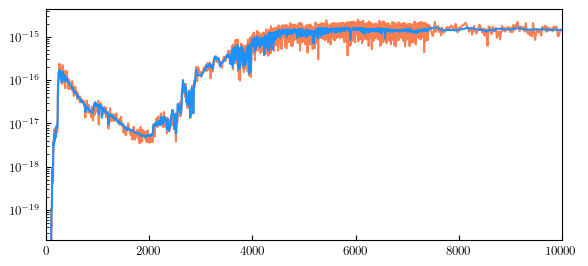

In [3]:
csp = CSPBasis(ssp_data, dusty=False, add_neb=False)
csp.add_sfh(sfr_old, lookback_time=tau)
csp.add_zh(zh, lookback_time=tau)
spec = csp.get_spectrum()

rng_key = jax.random.PRNGKey(42)

key, rng_key = jax.random.split(rng_key)
sigma = 0.2 * spec  # relative noise level
noise = sigma * jax.random.normal(key, shape=spec.shape)
spectrum_obs = spec + noise


plt.figure(figsize=(20/3, 3))
plt.plot(csp.wave, fnu2flam(csp.wave, spec*1e-23*3631), label='SFH', color='dodgerblue')
plt.plot(csp.wave, fnu2flam(csp.wave, spectrum_obs*1e-23*3631), label='Observed', color='coral', zorder = 0)
plt.xlim(0, 10000)
plt.yscale('log')

# Likelihood

In [4]:
from functools import partial
csp = CSPBasis(ssp_data)

csp.add_sfh(sfh=sfr_old, lookback_time=tau) #need to set sfh_times 
model = partial(csp.get_spectrum_direct_dustfree)  # csp is now static

print(model)

lookback time
functools.partial(<bound method CSPBasis.get_spectrum_direct_dustfree of <CSPBasis Object>
-----------------------------------
Universe Age (tuniv): 13.8 Gyr
Tiny Log Time (tiny_logt): -10
Number of SSP Ages: 108
Number of SSP Metallicities: 12
Wavelength Range: 91.0 - 100000000.0 Å
Star Formation History:
  SFH Times (lookback): [1.3790000e+10 1.3064210e+10 1.2338421e+10 1.1612632e+10 1.0886842e+10
 1.0161053e+10 9.4352630e+09 8.7094743e+09 7.9836846e+09 7.2578944e+09
 6.5321052e+09 5.8063160e+09 5.0805263e+09 4.3547372e+09 3.6289482e+09
 2.9031572e+09 2.1773681e+09 1.4515791e+09 7.2578906e+08 0.0000000e+00]
  SFH Values: [2.0148307e-01 5.6763738e-01 9.4434440e-01 9.2771840e-01 5.3818142e-01
 1.8436024e-01 3.7293404e-02 4.4547748e-03 3.1422684e-04 1.3088428e-05
 3.2192878e-07 4.6758233e-09 4.0103480e-11 2.0311148e-13 6.0745455e-16
 1.0727845e-18 1.1187820e-21 6.8897662e-25 2.5054432e-28 5.3801859e-32]
Spectrum: Not computed yet
Dust Model: Dust Model Configuration
Number

In [5]:
model = jax.jit(model)
spectrum = model(sfr_old, zh)

# grad also works (with respect to sfh, for example)
grad_spectrum = grad(lambda sfh: jnp.sum(model(sfh, zh)))(sfr_old)
print(model)
print('JIT and grad work!')

<PjitFunction of functools.partial(<bound method CSPBasis.get_spectrum_direct_dustfree of <CSPBasis Object>
-----------------------------------
Universe Age (tuniv): 13.8 Gyr
Tiny Log Time (tiny_logt): -10
Number of SSP Ages: 108
Number of SSP Metallicities: 12
Wavelength Range: 91.0 - 100000000.0 Å
Star Formation History:
  SFH Times (lookback): [1.3790000e+10 1.3064210e+10 1.2338421e+10 1.1612632e+10 1.0886842e+10
 1.0161053e+10 9.4352630e+09 8.7094743e+09 7.9836846e+09 7.2578944e+09
 6.5321052e+09 5.8063160e+09 5.0805263e+09 4.3547372e+09 3.6289482e+09
 2.9031572e+09 2.1773681e+09 1.4515791e+09 7.2578906e+08 0.0000000e+00]
  SFH Values: [2.0148307e-01 5.6763738e-01 9.4434440e-01 9.2771840e-01 5.3818142e-01
 1.8436024e-01 3.7293404e-02 4.4547748e-03 3.1422684e-04 1.3088428e-05
 3.2192878e-07 4.6758233e-09 4.0103480e-11 2.0311148e-13 6.0745455e-16
 1.0727845e-18 1.1187820e-21 6.8897662e-25 2.5054432e-28 5.3801859e-32]
Spectrum: Not computed yet
Dust Model: Dust Model Configuration
Num

In [6]:

def unpack_params(params_flat, n_bins):
    sfh = jnp.array([params_flat[f"sfh_{i}"] for i in range(n_bins)])
    zh  = jnp.array([params_flat[f"zh_{i}"]  for i in range(n_bins)])
    sigma = jnp.array(params_flat["sigma"])
    return sfh, zh, sigma

@jit
def loglikelihood_fn(params_flat):
    sfh, zh, sigma = unpack_params(params_flat, n_bins=N_T)
    mu = model(sfh, zh)
    cov = sigma ** 2
    lgl = jax.scipy.stats.multivariate_normal.logpdf(spectrum_obs, mu, cov)
    return lgl

In [7]:
max(sfr_old)

Array(0.9443444, dtype=float32)

# Prior

In [8]:

def unpack_params(params_flat, n_bins):
    sfh = jnp.array([params_flat[f"sfh_{i}"] for i in range(n_bins)])
    zh  = jnp.array([params_flat[f"zh_{i}"]  for i in range(n_bins)])
    sigma = jnp.array(params_flat["sigma"])
    return sfh, zh, sigma

@jit
def loglikelihood_fn(params_flat):
    sfh, zh, sigma = unpack_params(params_flat, n_bins=N_T)
    mu = model(sfh, zh)
    cov = sigma ** 2
    lgl = jax.scipy.stats.multivariate_normal.logpdf(spectrum_obs, mu, cov)
    return lgl


from blackjax.ns.utils import uniform_prior

prior_bounds = {**{f"sfh_{i}": (0.0, 10.0) for i in range(N_T)},
                **{f"zh_{i}": (5e-5, 0.02) for i in range(N_T)},
                "sigma": (1e-7, 1e-5)}


#Define hyperparamters for rfitting:
rng_key = jax.random.PRNGKey(0)
num_dims = N_T * 2 + 1 #star formation history, metallicity history and sigma
num_live = 100
num_inner_steps = num_dims * 5
num_delete = num_live // 5

rng_key, prior_key = jax.random.split(rng_key)
particles, logprior_fn = uniform_prior(prior_key, num_live, prior_bounds)




sfh_test0 = jnp.linspace(2.0, 6.0, N_T)     # example trend for test 0
sfh_test1 = jnp.linspace(3.0, 7.0, N_T)     # example trend for test 1
sfh_batch = jnp.stack([sfh_test0, sfh_test1], axis=0)  # (B, N_T)

# zh in [5e-5, 2e-2] — keep well inside bounds
zh_test0 = jnp.linspace(1.0e-4, 9.0e-4, N_T)
zh_test1 = jnp.linspace(4.0e-4, 1.5e-3, N_T)
zh_batch = jnp.stack([zh_test0, zh_test1], axis=0)     # (B, N_T)

# sigma (one per test)
sigma_batch = jnp.array([5.9143e-3, 1.0e-3])           # (B,)

# ---- assemble per-bin dict expected by your current loglikelihood_fn ----
params_test = {**{f"sfh_{i}": sfh_batch[:, i] for i in range(N_T)},
               **{f"zh_{i}":  zh_batch[:, i]  for i in range(N_T)},
               "sigma": sigma_batch}


lls = jax.vmap(loglikelihood_fn)(params_test)
print(f"Log-likelihoods for test parameters: {lls}")


Log-likelihoods for test parameters: [25243.06  35879.926]


# NEsted Sampler

In [9]:
nested_sampler = blackjax.nss(
    logprior_fn=logprior_fn,
    loglikelihood_fn=loglikelihood_fn,
    num_delete=num_delete,
    num_inner_steps=num_inner_steps,
    )

init_fn = jax.jit(nested_sampler.init)
step_fn = jax.jit(nested_sampler.step)
live = init_fn(particles)

Starting sampling...


Dead points: 0 dead points [00:00, ? dead points/s]

Current logZ: inf


Dead points: 40 dead points [02:15,  3.94s/ dead points]

Current logZ: 2270762.0


...

Current logZ: 73.625


Dead points: 17520 dead points [220:50:37,  7.33s/ dead points]

Current logZ: 69.28125


Dead points: 17540 dead points [220:52:55,  7.20s/ dead points]

Current logZ: 65.09375
